## Importing The Libraries

In [2]:
import numpy as np # used to make numpy arrays
import pandas as pd # used to make dataframe(structured table)
import matplotlib.pyplot as plt
import seaborn as sns # used for making some plots
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics # used to evaluate our model

## Date Collection and Processing

In [3]:
gold_data = pd.read_csv('/content/gld_price_data.csv') #loading the csv data to a pandas dataframe

In [4]:
print(gold_data.head()) # print irst five rows of dataset

       Date          SPX        GLD        USO     SLV   EUR/USD
0  1/2/2008  1447.160034  84.860001  78.470001  15.180  1.471692
1  1/3/2008  1447.160034  85.570000  78.370003  15.285  1.474491
2  1/4/2008  1411.630005  85.129997  77.309998  15.167  1.475492
3  1/7/2008  1416.180054  84.769997  75.500000  15.053  1.468299
4  1/8/2008  1390.189941  86.779999  76.059998  15.590  1.557099


In [5]:
print(gold_data.tail()) # print last five rows of dataset

           Date          SPX         GLD      USO      SLV   EUR/USD
2285   5/8/2018  2671.919922  124.589996  14.0600  15.5100  1.186789
2286   5/9/2018  2697.790039  124.330002  14.3700  15.5300  1.184722
2287  5/10/2018  2723.070068  125.180000  14.4100  15.7400  1.191753
2288  5/14/2018  2730.129883  124.489998  14.3800  15.5600  1.193118
2289  5/16/2018  2725.780029  122.543800  14.4058  15.4542  1.182033


In [6]:
# number of rows and columns
gold_data.shape # print(gold_data.shape) => (rows, columns)

(2290, 6)

In [7]:
# getting some basic information about the data
gold_data.info()

# here we don't have any missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [8]:
# checking the number of missing values
# gold_data.isnull() # give full dataframe with True or False, so we can use instead of this
gold_data.isnull().sum()

# if we have any missing values we can use method called imputation
# in imputation, we use mean or median values for handling the missing values

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [9]:
# getting the statistical measures of the data
gold_data.describe()

# count - no. of datapoints
# 25% (percentile) - 25% of values less than 1239.874969 in case of SPX

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Correlation:
1. Positive Correlation
2. Negative Correlation

while working on regresion projects, we will always check correlations i.e which column are related to which column.

In Positive Correlation we take 2 variables, one will increase and other will also increase (directly proportional to each other)

In Negative Correlation, one variable will increase and other will decrease (inversely proportional to each other)

Ex:- if gold price inc. then silver price also increases then these two are positively correlated.

In [10]:
correlation = gold_data.corr()

<ipython-input-10-e00263e44518>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation = gold_data.corr()


<Axes: >

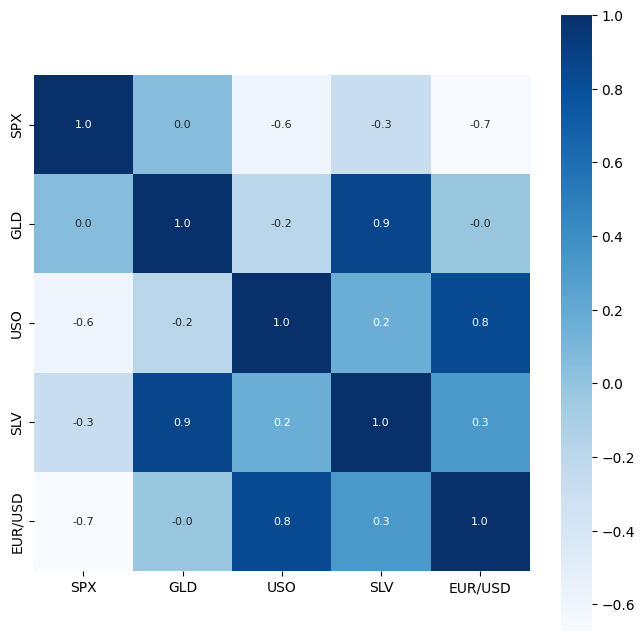

In [12]:
# constructing a heatmap to understand the correlation
plt.figure(figsize = (8,8))
sns.heatmap(correlation, cbar = True, square = True, fmt = '.1f', annot = True, annot_kws = {'size':8}, cmap = 'Blues')

# here gold is positively correalated with silver according to graph
# shade of colour shows highly correlated or light correlated, dark blue shade shows highly positive correlated
# 0 means they are not correlated

correlation: This is the core data you want to visualize. It's assumed to be a 2D array representing a correlation matrix, where each cell represents the correlation coefficient between two variables.

cbar = True: This argument controls the colorbar. Setting it to True displays a colorbar on the side of the heatmap, which helps interpret the color scale used to represent correlation values.

square = True: This ensures the heatmap is square-shaped, with the same number of rows and columns as the input correlation matrix.

fmt = '.1f': This defines the format for displaying correlation values within each heatmap cell. The .1f format specifies one decimal place.

annot = True: This enables annotation within the heatmap cells. It displays the actual correlation coefficient values within each cell.

annot_kws = {'size': 8}: This dictionary argument controls the annotation properties. Here, 'size': 8 sets the font size of the annotated values to 8.

cmap = 'Blues': This argument defines the colormap used to represent the correlation values. The 'Blues' option specifies a blue color gradient, where darker shades typically represent higher positive correlations and lighter shades might represent negative correlations or values closer to zero.

Overall, this code snippet effectively creates a heatmap visualization of a correlation matrix, allowing you to explore the relationships between different variables based on their correlation coefficients. The customizations like the colorbar, square format, and annotations enhance the readability and interpretation of the heatmap.

In [14]:
# correlation values of gold
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


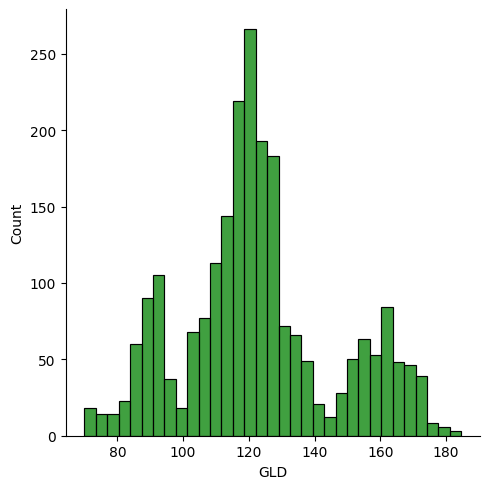

In [16]:
# checking the distribution of gold price
sns.displot(gold_data['GLD'], color='green') # we can use distplot but it will remove in next version of seaborn

# density of most values lie in the range of 120

## Splitting the features and target

In [18]:
X = gold_data.drop(['Date', 'GLD'], axis=1) # whenever you are dropping a column, then you have to give a parameter i.e axis=1 and axis=0 in case of rows
y = gold_data['GLD']

In [19]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [20]:
print(y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


## Splitting into Training data and Test data

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# we can give any value of random_state, role of random_state is it controls the shuffling for splitting data, allowing for reproducibility (fixed value) or exploration (default None).
# used to reproduce the code exactly in same way

RANDOM STATE

Imagine you have a deck of cards representing your data. train_test_split shuffles this deck and deals out two piles: training data and testing data.

Without random_state (default): Every time you run your code, it's like shuffling the deck with a brand new shuffle each time. This is good for exploring different model behaviors.

With random_state (fixed value): It's like using a specific shuffling technique (like a fancy cut) every time. This ensures you get the same split (piles of cards) whenever you run the code, making your results reproducible.

## Model Training: Random Forest Regression

Random forest regression follows the technique that a dataset is splitted into n number of trees and from each tree we have a result and final result will be by taking the average of all individual results or by majority voting, that's how we get final result.

Here's how the value of n_estimators affects our model:


**Higher n_estimators (more trees):**

Pros: Generally leads to better performance on the training data as the model can capture more complex relationships.

Cons: Increases training time and can lead to overfitting if not careful. Overfitting means the model performs well on the training data but poorly on unseen data.

**Lower n_estimators (fewer trees):**

Pros: Faster training time and potentially less prone to overfitting.

Cons: Might underfit the data, meaning the model is too simple to capture the underlying relationships, leading to lower accuracy.

In [23]:
regressor = RandomForestRegressor(n_estimators=100) # n_estimators tells us about number of decision trees we want to build in a forest and 100 is default value

# training the model
regressor.fit(X_train, y_train) # fit() function will fit our data to this model and by this our ML model will be trained

RandomForestRegressor()

## Model Evaluation

In [24]:
# prediction on test data

test_data_prediction = regressor.predict(X_test)

In [25]:
print(test_data_prediction)

[168.60079942  82.07239982 115.85160018 127.88000074 120.88040131
 154.68449778 150.32319906 126.19459998 117.51279891 126.0146005
 116.90850126 171.1682008  141.80179857 168.08009916 115.04340007
 117.89760066 138.02930361 170.25120139 159.86690213 160.12609961
 155.1058996  125.16190024 175.63369974 156.94790349 125.27610051
  93.72829991  76.79530051 120.62520006 119.09189926 167.32469988
  88.2992002  125.55000049  91.07370066 117.8316003  121.1831992
 137.61950096 115.34580118 115.16440085 145.9489998  107.38320098
 104.46800229  87.17459788 126.46310041 117.76279966 153.80259875
 119.53290051 108.36429987 108.10269845  93.17890067 127.00329821
  75.00100004 113.74659948 121.51870023 111.30159933 118.86409893
 120.26709953 158.90520043 166.74350078 146.88859675  86.02859891
  94.32760063  86.76189863  90.57270093 118.91610086 126.34630068
 127.3946999  169.82669991 122.26499913 117.41819901  98.70300045
 168.58360039 143.02899786 132.25010177 121.25810214 120.67369933
 119.8020003

In [26]:
# R squared error to measure performance

error_score = metrics.r2_score(y_test, test_data_prediction) # here we need to mention real values and predicted values
print("R squared error: ", error_score)

R squared error:  0.9896398214879403


## Compare Actual Values and Predicted Values in a Plot

In [27]:
y_list = list(y_test)

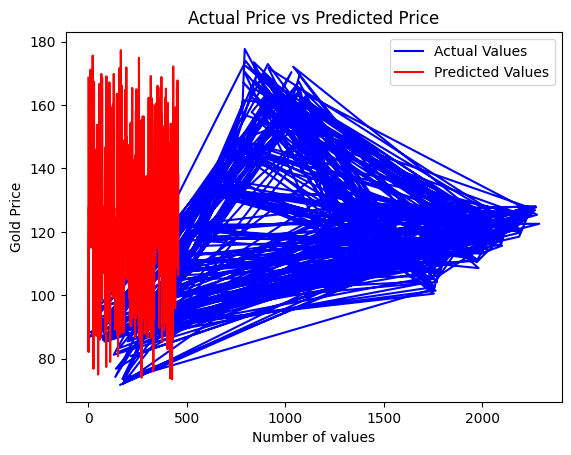

In [32]:
plt.plot(y_test, color='blue', label='Actual Values')
plt.plot(test_data_prediction, color='red', label='Predicted Values')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('Gold Price')
plt.legend() #serves a crucial purpose in enhancing the clarity and readability of your plots, especially when you have multiple lines or elements visualised
plt.show()